# Level 3 Project 2 – GitHub Machine Learning Repositories

## Task 1: Data Collection & Preparation

In [1]:
#import libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
# retrieve data from the github API

url = 'https://api.github.com/search/repositories?q=machine+learning&per_page=100'
headers = {
    'Accept': 'application/vnd.github+json',
    'X-GitHub-Api-Version': '2022-11-28',
    'User-Agent': 'Mozilla/5.0'
}
response = requests.get(url, headers=headers)

response.status_code

200

In [3]:
# create the dataset
data = response.json()['items']
repositories = pd.DataFrame(data)
repositories.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15610,25,74054,master,1.0
1,27595858,MDEwOlJlcG9zaXRvcnkyNzU5NTg1OA==,MachineLearning,wepe/MachineLearning,False,"{'login': 'wepe', 'id': 9136322, 'node_id': 'M...",https://github.com/wepe/MachineLearning,Basic Machine Learning and Deep Learning,False,https://api.github.com/repos/wepe/MachineLearning,...,False,True,all,[],public,3206,50,5747,master,1.0
2,71154529,MDEwOlJlcG9zaXRvcnk3MTE1NDUyOQ==,MachineLearning_Python,lawlite19/MachineLearning_Python,False,"{'login': 'lawlite19', 'id': 14356062, 'node_i...",https://github.com/lawlite19/MachineLearning_P...,机器学习算法python实现,False,https://api.github.com/repos/lawlite19/Machine...,...,False,True,all,[],public,2515,10,8580,master,1.0
3,86140645,MDEwOlJlcG9zaXRvcnk4NjE0MDY0NQ==,Machine-Learning,Jack-Cherish/Machine-Learning,False,"{'login': 'Jack-Cherish', 'id': 16872370, 'nod...",https://github.com/Jack-Cherish/Machine-Learning,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,False,https://api.github.com/repos/Jack-Cherish/Mach...,...,False,True,all,"[adaboost, adaboost-algorithm, decision-tree, ...",public,5065,7,10370,master,1.0
4,50450433,MDEwOlJlcG9zaXRvcnk1MDQ1MDQzMw==,machine-learning,udacity/machine-learning,False,"{'login': 'udacity', 'id': 1916665, 'node_id':...",https://github.com/udacity/machine-learning,Content for Udacity's Machine Learning curriculum,False,https://api.github.com/repos/udacity/machine-l...,...,False,True,all,[],public,6233,0,4030,master,1.0


In [4]:
repositories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   94 non-null     object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [5]:
repositories.shape

(100, 82)

In [6]:
repositories.dtypes

,0
id,int64
node_id,object
name,object
full_name,object
private,bool
...,...
forks,int64
open_issues,int64
watchers,int64
default_branch,object


In [7]:
repositories.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [8]:
#select required columns
df1=repositories[['name','full_name','owner','license','description','language','stargazers_count','forks_count','open_issues_count','created_at','updated_at','html_url']]
df1.head()

,name,full_name,owner,license,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,html_url
0,awesome-machine-learning,josephmisiti/awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...","{'key': 'other', 'name': 'Other', 'spdx_id': '...",A curated list of awesome Machine Learning fra...,Python,74054,15610,25,2014-07-15T19:11:19Z,2026-08-18T11:27:04Z,https://github.com/josephmisiti/awesome-machin...
1,MachineLearning,wepe/MachineLearning,"{'login': 'wepe', 'id': 9136322, 'node_id': 'M...",None,Basic Machine Learning and Deep Learning,Python,5747,3206,50,2014-12-05T14:53:17Z,2026-08-18T08:09:56Z,https://github.com/wepe/MachineLearning
2,MachineLearning_Python,lawlite19/MachineLearning_Python,"{'login': 'lawlite19', 'id': 14356062, 'node_i...","{'key': 'mit', 'name': 'MIT License', 'spdx_id...",机器学习算法python实现,Python,8580,2515,10,2016-10-17T15:44:59Z,2026-08-18T06:33:54Z,https://github.com/lawlite19/MachineLearning_P...
3,Machine-Learning,Jack-Cherish/Machine-Learning,"{'login': 'Jack-Cherish', 'id': 16872370, 'nod...",None,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,Python,10370,5065,7,2017-03-25T07:32:37Z,2026-08-18T03:26:09Z,https://github.com/Jack-Cherish/Machine-Learning
4,machine-learning,udacity/machine-learning,"{'login': 'udacity', 'id': 1916665, 'node_id':...",None,Content for Udacity's Machine Learning curriculum,Jupyter Notebook,4030,6233,0,2016-01-26T18:41:03Z,2026-08-17T21:37:20Z,https://github.com/udacity/machine-learning


In [9]:
#extract required values from nested columns
df1['owner']=df1['owner'].apply(lambda x: x['login'])
df1['license']=df1['license'].apply(lambda x: x['spdx_id'] if x else 'Unknown')
df1.head()

/tmp/ipykernel_2009/472517225.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['owner']=df1['owner'].apply(lambda x: x['login'])
/tmp/ipykernel_2009/472517225.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['license']=df1['license'].apply(lambda x: x['spdx_id'] if x else 'Unknown')


,name,full_name,owner,license,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,html_url
0,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,NOASSERTION,A curated list of awesome Machine Learning fra...,Python,74054,15610,25,2014-07-15T19:11:19Z,2026-08-18T11:27:04Z,https://github.com/josephmisiti/awesome-machin...
1,MachineLearning,wepe/MachineLearning,wepe,Unknown,Basic Machine Learning and Deep Learning,Python,5747,3206,50,2014-12-05T14:53:17Z,2026-08-18T08:09:56Z,https://github.com/wepe/MachineLearning
2,MachineLearning_Python,lawlite19/MachineLearning_Python,lawlite19,MIT,机器学习算法python实现,Python,8580,2515,10,2016-10-17T15:44:59Z,2026-08-18T06:33:54Z,https://github.com/lawlite19/MachineLearning_P...
3,Machine-Learning,Jack-Cherish/Machine-Learning,Jack-Cherish,Unknown,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,Python,10370,5065,7,2017-03-25T07:32:37Z,2026-08-18T03:26:09Z,https://github.com/Jack-Cherish/Machine-Learning
4,machine-learning,udacity/machine-learning,udacity,Unknown,Content for Udacity's Machine Learning curriculum,Jupyter Notebook,4030,6233,0,2016-01-26T18:41:03Z,2026-08-17T21:37:20Z,https://github.com/udacity/machine-learning


In [10]:
#clean data : nulls
df1.isnull().sum()

,0
name,0
full_name,0
owner,0
license,0
description,6
language,31
stargazers_count,0
forks_count,0
open_issues_count,0
created_at,0


In [11]:
#handle nulls
df1['description']=df1['description'].fillna('No description')
df1['language']=df1['language'].fillna('Unknown')
df1['license']=df1['license'].fillna('Unknown')
df1.isnull().sum()

/tmp/ipykernel_2009/163262903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['description']=df1['description'].fillna('No description')
/tmp/ipykernel_2009/163262903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['language']=df1['language'].fillna('Unknown')
/tmp/ipykernel_2009/163262903.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

,0
name,0
full_name,0
owner,0
license,0
description,0
language,0
stargazers_count,0
forks_count,0
open_issues_count,0
created_at,0


In [12]:
#clean data : duplicates
df1.duplicated().sum()

np.int64(0)

In [13]:
df1=df1.drop_duplicates()
df1.shape

(100, 12)

In [14]:
df1.dtypes

,0
name,object
full_name,object
owner,object
license,object
description,object
language,object
stargazers_count,int64
forks_count,int64
open_issues_count,int64
created_at,object


In [15]:
#change data type
df1['created_at']=pd.to_datetime(df1['created_at'])
df1['updated_at']=pd.to_datetime(df1['updated_at'])

In [16]:
df1['stargazers_count']=pd.to_numeric(df1['stargazers_count'])
df1['forks_count']=pd.to_numeric(df1['forks_count'])
df1['open_issues_count']=pd.to_numeric(df1['open_issues_count'])

In [17]:
df1.dtypes

,0
name,object
full_name,object
owner,object
license,object
description,object
language,object
stargazers_count,int64
forks_count,int64
open_issues_count,int64
created_at,"datetime64[ns, UTC]"


In [18]:
#rename columns
df1.rename(
    columns={'name':'Name','full_name':'Full Name','owner':'Owner','license':'License',
             'description':'Description','language':'Language','stargazers_count':'Stars',
             'forks_count':'Forks','open_issues_count':'Open Issues','created_at':'Created At',
             'updated_at':'Updated At','html_url':'GitHub URL'},
           inplace=True)
df1.head()

,Name,Full Name,Owner,License,Description,Language,Stars,Forks,Open Issues,Created At,Updated At,GitHub URL
0,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,NOASSERTION,A curated list of awesome Machine Learning fra...,Python,74054,15610,25,2014-07-15 19:11:19+00:00,2026-08-18 11:27:04+00:00,https://github.com/josephmisiti/awesome-machin...
1,MachineLearning,wepe/MachineLearning,wepe,Unknown,Basic Machine Learning and Deep Learning,Python,5747,3206,50,2014-12-05 14:53:17+00:00,2026-08-18 08:09:56+00:00,https://github.com/wepe/MachineLearning
2,MachineLearning_Python,lawlite19/MachineLearning_Python,lawlite19,MIT,机器学习算法python实现,Python,8580,2515,10,2016-10-17 15:44:59+00:00,2026-08-18 06:33:54+00:00,https://github.com/lawlite19/MachineLearning_P...
3,Machine-Learning,Jack-Cherish/Machine-Learning,Jack-Cherish,Unknown,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,Python,10370,5065,7,2017-03-25 07:32:37+00:00,2026-08-18 03:26:09+00:00,https://github.com/Jack-Cherish/Machine-Learning
4,machine-learning,udacity/machine-learning,udacity,Unknown,Content for Udacity's Machine Learning curriculum,Jupyter Notebook,4030,6233,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,https://github.com/udacity/machine-learning


In [19]:
#save cleaned dataset
df1.to_csv('github_projects.csv',index=False)

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
#reload file
repositories=pd.read_csv('github_projects.csv')
repositories.head()

,Name,Full Name,Owner,License,Description,Language,Stars,Forks,Open Issues,Created At,Updated At,GitHub URL
0,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,NOASSERTION,A curated list of awesome Machine Learning fra...,Python,74054,15610,25,2014-07-15 19:11:19+00:00,2026-08-18 11:27:04+00:00,https://github.com/josephmisiti/awesome-machin...
1,MachineLearning,wepe/MachineLearning,wepe,Unknown,Basic Machine Learning and Deep Learning,Python,5747,3206,50,2014-12-05 14:53:17+00:00,2026-08-18 08:09:56+00:00,https://github.com/wepe/MachineLearning
2,MachineLearning_Python,lawlite19/MachineLearning_Python,lawlite19,MIT,机器学习算法python实现,Python,8580,2515,10,2016-10-17 15:44:59+00:00,2026-08-18 06:33:54+00:00,https://github.com/lawlite19/MachineLearning_P...
3,Machine-Learning,Jack-Cherish/Machine-Learning,Jack-Cherish,Unknown,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,Python,10370,5065,7,2017-03-25 07:32:37+00:00,2026-08-18 03:26:09+00:00,https://github.com/Jack-Cherish/Machine-Learning
4,machine-learning,udacity/machine-learning,udacity,Unknown,Content for Udacity's Machine Learning curriculum,Jupyter Notebook,4030,6233,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,https://github.com/udacity/machine-learning


In [22]:
repositories['Created At']=pd.to_datetime(repositories['Created At'])
repositories['Updated At']=pd.to_datetime(repositories['Updated At'])

## Task 2: Store & Analyse the Data

In [23]:
#install sql
!pip install ipython-sql==0.5.0 prettytable==3.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: prettytable
    Found existing installation: prettytable 3.18.0
    Uninstalling prettytable-3.18.0:
      Successfully uninstalled prettytable-3.18.0


In [24]:
%load_ext sql

%config SqlMagic.style = 'PLAIN_COLUMNS'

%sql sqlite:///github_projects.db

In [25]:
import sqlite3
conn=sqlite3.connect('github_projects.db')
repositories.to_sql('Repositories',conn,if_exists="replace",
    index=False)

100

In [26]:
%%sql
SELECT * FROM Repositories

 * sqlite:///github_projects.db
Done.


Name,Full Name,Owner,License,Description,Language,Stars,Forks,Open Issues,Created At,Updated At,GitHub URL
awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,NOASSERTION,"A curated list of awesome Machine Learning frameworks, libraries and software.",Python,74054,15610,25,2014-07-15 19:11:19+00:00,2026-08-18 11:27:04+00:00,https://github.com/josephmisiti/awesome-machine-learning
MachineLearning,wepe/MachineLearning,wepe,Unknown,Basic Machine Learning and Deep Learning,Python,5747,3206,50,2014-12-05 14:53:17+00:00,2026-08-18 08:09:56+00:00,https://github.com/wepe/MachineLearning
MachineLearning_Python,lawlite19/MachineLearning_Python,lawlite19,MIT,机器学习算法python实现,Python,8580,2515,10,2016-10-17 15:44:59+00:00,2026-08-18 06:33:54+00:00,https://github.com/lawlite19/MachineLearning_Python
Machine-Learning,Jack-Cherish/Machine-Learning,Jack-Cherish,Unknown,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归、树回归,Python,10370,5065,7,2017-03-25 07:32:37+00:00,2026-08-18 03:26:09+00:00,https://github.com/Jack-Cherish/Machine-Learning
machine-learning,udacity/machine-learning,udacity,Unknown,Content for Udacity's Machine Learning curriculum,Jupyter Notebook,4030,6233,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,https://github.com/udacity/machine-learning
MachineLearningNotebooks,Azure/MachineLearningNotebooks,Azure,MIT,Python notebooks with ML and deep learning examples with Azure Machine Learning Python SDK | Microsoft,Jupyter Notebook,4424,2574,400,2018-08-17 17:29:14+00:00,2026-08-16 23:55:04+00:00,https://github.com/Azure/MachineLearningNotebooks
homemade-machine-learning,trekhleb/homemade-machine-learning,trekhleb,MIT,🤖 Python examples of popular machine learning algorithms with interactive Jupyter demos and math being explained,Jupyter Notebook,24762,4194,31,2018-11-01 04:34:19+00:00,2026-08-18 08:38:14+00:00,https://github.com/trekhleb/homemade-machine-learning
machine_learning_examples,lazyprogrammer/machine_learning_examples,lazyprogrammer,Unknown,A collection of machine learning examples and tutorials.,Python,8911,6404,33,2014-07-31 23:40:45+00:00,2026-08-18 09:26:41+00:00,https://github.com/lazyprogrammer/machine_learning_examples
Machine-Learning-Tutorials,ujjwalkarn/Machine-Learning-Tutorials,ujjwalkarn,CC0-1.0,"machine learning and deep learning tutorials, articles and other resources",Unknown,18108,3969,47,2015-09-12 14:51:38+00:00,2026-08-18 01:43:01+00:00,https://github.com/ujjwalkarn/Machine-Learning-Tutorials
machine-learning-for-trading,stefan-jansen/machine-learning-for-trading,stefan-jansen,MIT,"Code for Machine Learning for Trading, 3rd edition — from data sourcing to live execution.",Jupyter Notebook,20495,5525,6,2018-05-09 12:33:08+00:00,2026-08-18 09:51:22+00:00,https://github.com/stefan-jansen/machine-learning-for-trading


In [27]:
%%sql
SELECT Name, Owner, Stars
FROM Repositories
WHERE Stars > 1000
ORDER BY Stars DESC
LIMIT 10;

 * sqlite:///github_projects.db
Done.


Name,Owner,Stars
tensorflow,tensorflow,197035
awesome-machine-learning,josephmisiti,74054
scikit-learn,scikit-learn,66967
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,36350
netron,lutzroeder,33363
machine-learning-for-software-engineers,ZuzooVn,28861
cs249r_book,harvard-edge,27950
homemade-machine-learning,trekhleb,24762
onnx,onnx,21325
awesome-production-machine-learning,EthicalML,20851


In [28]:
%%sql
SELECT Name, Language, Stars
FROM Repositories
WHERE Stars > 500 AND Forks > 50
ORDER BY Stars DESC
LIMIT 10;

 * sqlite:///github_projects.db
Done.


Name,Language,Stars
tensorflow,C++,197035
awesome-machine-learning,Python,74054
scikit-learn,Python,66967
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36350
netron,JavaScript,33363
machine-learning-for-software-engineers,Unknown,28861
cs249r_book,Python,27950
homemade-machine-learning,Jupyter Notebook,24762
onnx,Python,21325
awesome-production-machine-learning,Unknown,20851


In [29]:
%%sql
SELECT Name, Language, Stars
FROM Repositories
WHERE Language = 'Python' OR Language = 'Jupyter Notebook'
ORDER BY Stars DESC
LIMIT 10;

 * sqlite:///github_projects.db
Done.


Name,Language,Stars
awesome-machine-learning,Python,74054
scikit-learn,Python,66967
cs249r_book,Python,27950
homemade-machine-learning,Jupyter Notebook,24762
onnx,Python,21325
machine-learning-for-trading,Jupyter Notebook,20495
numpy-ml,Python,16335
ivy,Python,14170
machine-learning-zoomcamp,Jupyter Notebook,13933
tvm,Python,13669


In [30]:
%%sql
SELECT Name, Language, Stars
FROM Repositories
WHERE NOT Language = 'Unknown'
ORDER BY Stars DESC
LIMIT 10;

 * sqlite:///github_projects.db
Done.


Name,Language,Stars
tensorflow,C++,197035
awesome-machine-learning,Python,74054
scikit-learn,Python,66967
netron,JavaScript,33363
cs249r_book,Python,27950
homemade-machine-learning,Jupyter Notebook,24762
onnx,Python,21325
machine-learning-for-trading,Jupyter Notebook,20495
numpy-ml,Python,16335
ggml,C++,15188


In [31]:
%%sql
SELECT COUNT(*) AS total_repositories
FROM Repositories;

 * sqlite:///github_projects.db
Done.


total_repositories
100


In [32]:
%%sql
SELECT AVG(Stars) AS avg_stars
FROM Repositories;

 * sqlite:///github_projects.db
Done.


avg_stars
10776.28


In [33]:
%%sql
SELECT Language, COUNT(*) AS repository_count, AVG(Stars) AS avg_stars
FROM Repositories
GROUP BY Language
HAVING COUNT(*) > 1
ORDER BY repository_count DESC;

 * sqlite:///github_projects.db
Done.


Language,repository_count,avg_stars
Jupyter Notebook,36,5415.944444444444
Unknown,31,8805.0
Python,22,14454.818181818182
HTML,3,5887.666666666667
MATLAB,2,1605.0
C++,2,106111.5


In [34]:
%%sql
SELECT License, COUNT(*) AS repository_count
FROM Repositories
GROUP BY License
HAVING COUNT(*) > 1
ORDER BY repository_count DESC;

 * sqlite:///github_projects.db
Done.


License,repository_count
Unknown,46
MIT,26
NOASSERTION,8
Apache-2.0,8
GPL-3.0,3
CC0-1.0,3
CC-BY-SA-4.0,2
BSD-3-Clause,2


### Python Visualizations

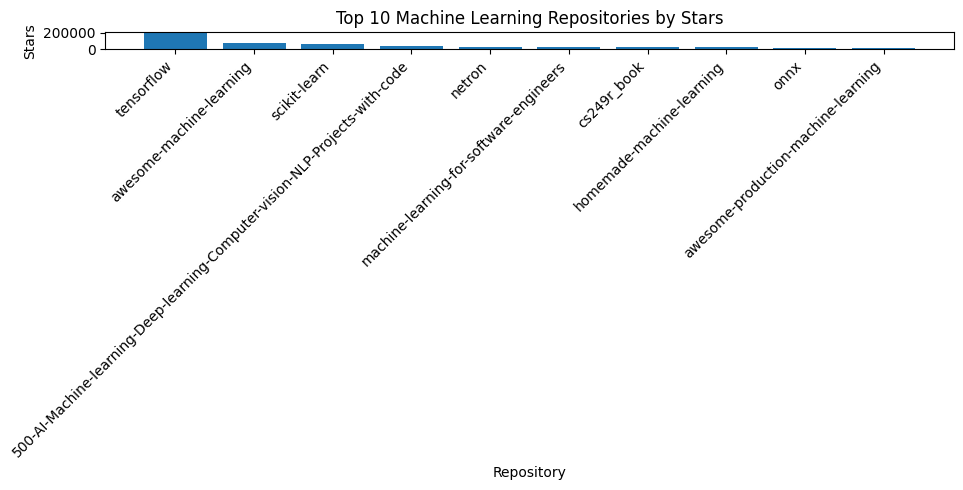

In [35]:
# top repositories by stars
top_repositories = repositories.sort_values('Stars',ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_repositories['Name'],top_repositories['Stars'])
plt.xticks(rotation=45,ha='right')
plt.xlabel('Repository')
plt.ylabel('Stars')
plt.title('Top 10 Machine Learning Repositories by Stars')
plt.tight_layout()
plt.show()

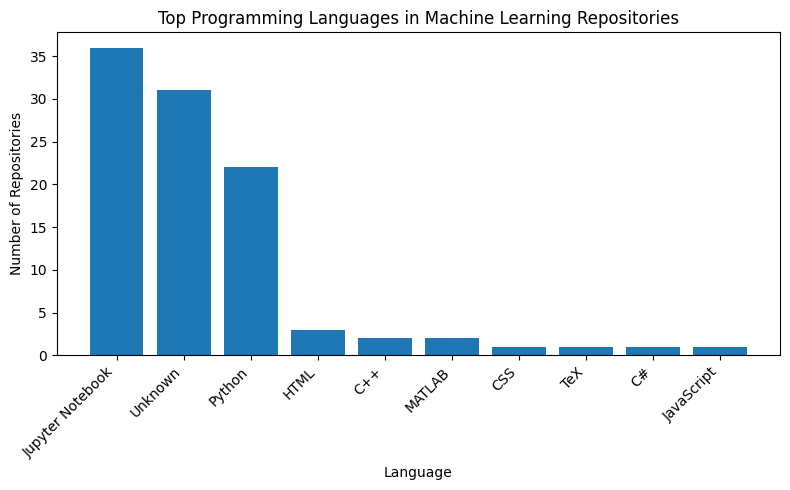

In [36]:
# repositories by language
language_counts = repositories['Language'].value_counts().head(10)
plt.figure(figsize=(8,5))
plt.bar(language_counts.index,language_counts.values)
plt.xticks(rotation=45,ha='right')
plt.xlabel('Language')
plt.ylabel('Number of Repositories')
plt.title('Top Programming Languages in Machine Learning Repositories')
plt.tight_layout()
plt.show()

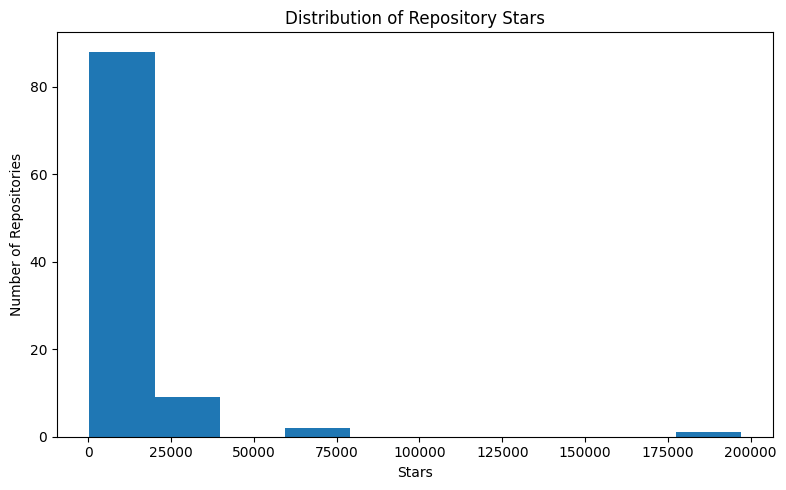

In [37]:
# stars distribution
plt.figure(figsize=(8,5))
plt.hist(repositories['Stars'],bins=10)
plt.xlabel('Stars')
plt.ylabel('Number of Repositories')
plt.title('Distribution of Repository Stars')
plt.tight_layout()
plt.show()

### Task 2 Findings

- Repositories with higher star counts are more popular within the collected Machine Learning dataset.
- The language analysis shows which programming languages are most common in the collected repositories.
- The SQL grouping results compare repository counts and average stars across languages and licenses.
- The charts visually support the SQL analysis and help identify the most popular repositories and languages.